In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
url = "/kaggle/input/smart-los/smart_logistics_dataset.csv"
url1 = "/kaggle/input/suply-data/dynamic_supply_chain_logistics_dataset.csv"
data = pd.read_csv(url)
data1 = pd.read_csv(url1)

# Show first 5 rows
print("First 5 rows from Used Car Price Dataset:")
##print(data.head())
print(data1.head())

First 5 rows from Used Car Price Dataset:
             timestamp  vehicle_gps_latitude  vehicle_gps_longitude  \
0  2021-01-01 00:00:00             40.375568             -77.014318   
1  2021-01-01 01:00:00             33.507818            -117.036902   
2  2021-01-01 02:00:00             30.020640             -75.269224   
3  2021-01-01 03:00:00             36.649223             -70.190529   
4  2021-01-01 04:00:00             30.001279             -70.012195   

   fuel_consumption_rate  eta_variation_hours  traffic_congestion_level  \
0               5.136512             4.998009                  5.927586   
1               5.101512             0.984929                  1.591992   
2               5.090803             4.972665                  8.787765   
3               8.219558             3.095064                  0.045257   
4               5.000075             3.216077                  8.004851   

   warehouse_inventory_level  loading_unloading_time  \
0                 985.71

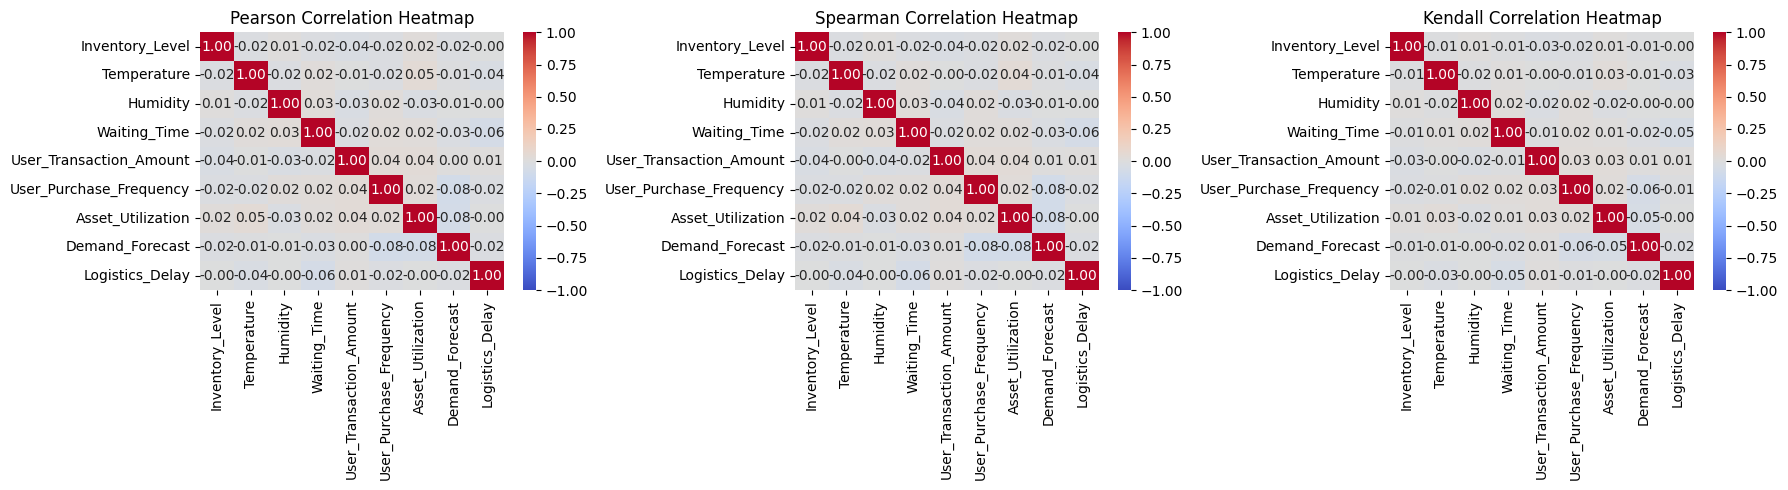

In [6]:
numeric_columns = [
    'Inventory_Level', 'Temperature', 'Humidity', 'Waiting_Time',
    'User_Transaction_Amount', 'User_Purchase_Frequency',
    'Asset_Utilization', 'Demand_Forecast', 'Logistics_Delay'
]

# Filter only numeric columns from the DataFrame
numeric_data_filtered = data[numeric_columns]

corr_methods = ['pearson', 'spearman', 'kendall']

plt.figure(figsize=(18, 5))  # Wider figure for multiple plots

for i, method in enumerate(corr_methods, 1):
    plt.subplot(1, 3, i)
    corr_matrix = numeric_data_filtered.corr(method=method)
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
    plt.title(f'{method.capitalize()} Correlation Heatmap')

plt.tight_layout()
plt.show()

In [15]:
print(data1.columns.tolist())

['timestamp', 'vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability', 'order_fulfillment_status', 'weather_condition_severity', 'port_congestion_level', 'shipping_costs', 'supplier_reliability_score', 'lead_time_days', 'historical_demand', 'iot_temperature', 'cargo_condition_status', 'route_risk_level', 'customs_clearance_time', 'driver_behavior_score', 'fatigue_monitoring_score', 'disruption_likelihood_score', 'delay_probability', 'risk_classification', 'delivery_time_deviation']


In [16]:
print(data1.columns)       
print(len(data1.columns))

Index(['timestamp', 'vehicle_gps_latitude', 'vehicle_gps_longitude',
       'fuel_consumption_rate', 'eta_variation_hours',
       'traffic_congestion_level', 'warehouse_inventory_level',
       'loading_unloading_time', 'handling_equipment_availability',
       'order_fulfillment_status', 'weather_condition_severity',
       'port_congestion_level', 'shipping_costs', 'supplier_reliability_score',
       'lead_time_days', 'historical_demand', 'iot_temperature',
       'cargo_condition_status', 'route_risk_level', 'customs_clearance_time',
       'driver_behavior_score', 'fatigue_monitoring_score',
       'disruption_likelihood_score', 'delay_probability',
       'risk_classification', 'delivery_time_deviation'],
      dtype='object')
26


In [3]:
from sklearn.ensemble import RandomForestClassifier

X = data1.drop('risk_classification', axis=1)
y = data1['risk_classification']

# Convert categorical variables if needed
X = pd.get_dummies(X, drop_first=True)

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)


disruption_likelihood_score    0.643348
shipping_costs                 0.007937
lead_time_days                 0.007826
delay_probability              0.007801
order_fulfillment_status       0.007800
vehicle_gps_longitude          0.007764
vehicle_gps_latitude           0.007733
delivery_time_deviation        0.007705
supplier_reliability_score     0.007702
customs_clearance_time         0.007682
dtype: float64

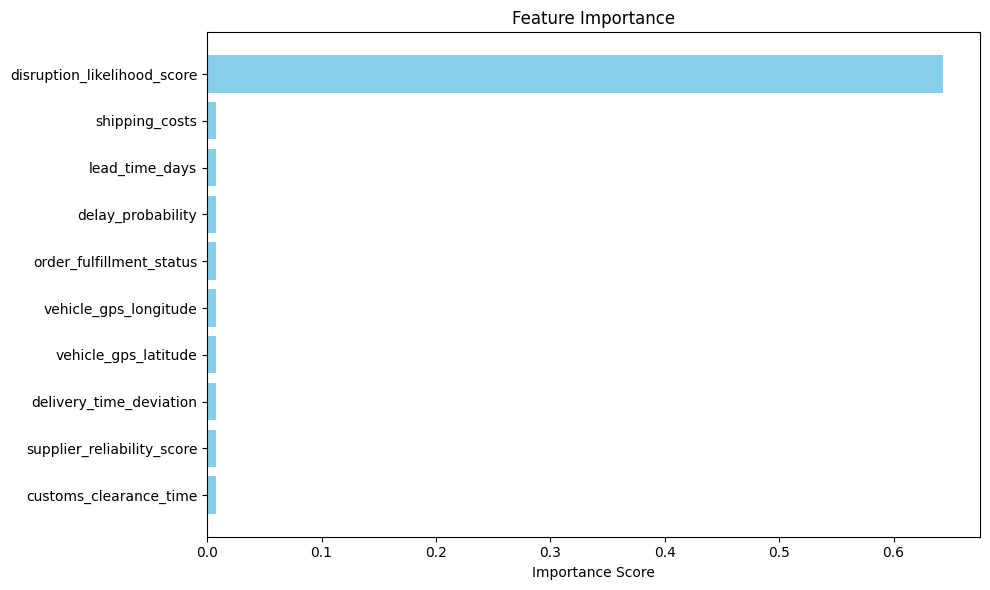

In [6]:
import matplotlib.pyplot as plt

# Data
features = [
    "disruption_likelihood_score", "shipping_costs", "lead_time_days",
    "delay_probability", "order_fulfillment_status", "vehicle_gps_longitude",
    "vehicle_gps_latitude", "delivery_time_deviation", "supplier_reliability_score",
    "customs_clearance_time"
]

values = [
    0.643348, 0.007937, 0.007826, 0.007801, 0.007800,
    0.007764, 0.007733, 0.007705, 0.007702, 0.007682
]

# Plot
plt.figure(figsize=(10,6))
plt.barh(features[::-1], values[::-1], color='skyblue')  # reverse for descending order
plt.xlabel("Importance Score")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()


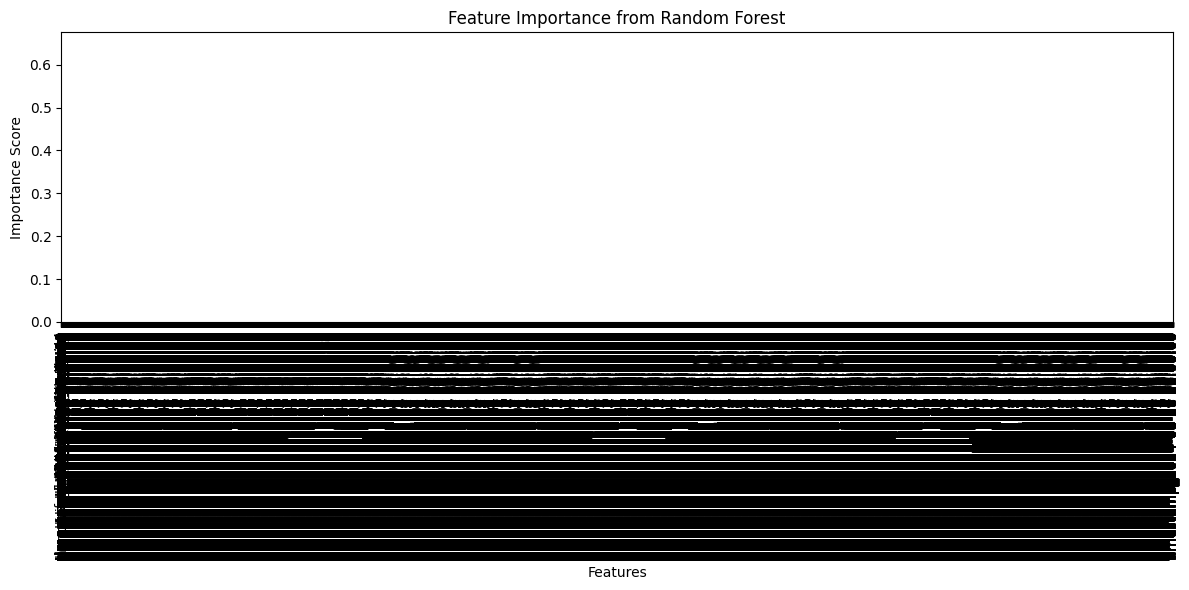

In [5]:
plt.figure(figsize=(12, 6))
importances.plot(kind='bar')

plt.title("Feature Importance from Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


top_features = [
    'disruption_likelihood_score',
    'shipping_costs',
    'lead_time_days',
    'delay_probability',
    'order_fulfillment_status',
    'vehicle_gps_longitude',
    'vehicle_gps_latitude',
    'delivery_time_deviation',
    'supplier_reliability_score',
    'customs_clearance_time'
]

X = data1[top_features]
y = data1['risk_classification']
y = y.astype('category').cat.codes

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9995322002183066

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4764
           1       1.00      1.00      1.00       641
           2       1.00      1.00      1.00      1008

    accuracy                           1.00      6413
   macro avg       1.00      1.00      1.00      6413
weighted avg       1.00      1.00      1.00      6413


Confusion Matrix:
 [[4764    0    0]
 [   0  641    0]
 [   2    1 1005]]


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


top_features_1 = [
    'shipping_costs',
    'lead_time_days',
    'delay_probability',
    'order_fulfillment_status',
    'vehicle_gps_longitude',
    'vehicle_gps_latitude',
    'delivery_time_deviation',
    'supplier_reliability_score',
    'customs_clearance_time'
]

X = data1[top_features_1]
y = data1['risk_classification']
y = y.astype('category').cat.codes

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7428660533291751

Classification Report:
               precision    recall  f1-score   support

           0       0.74      1.00      0.85      4764
           1       0.00      0.00      0.00       641
           2       0.00      0.00      0.00      1008

    accuracy                           0.74      6413
   macro avg       0.25      0.33      0.28      6413
weighted avg       0.55      0.74      0.63      6413


Confusion Matrix:
 [[4764    0    0]
 [ 641    0    0]
 [1008    0    0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


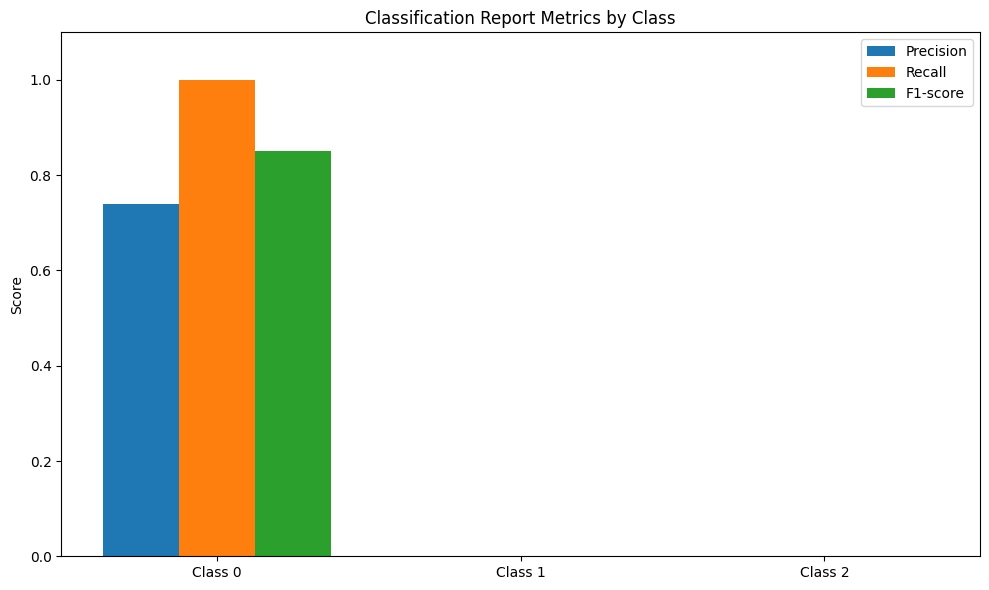

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# --- Metrics from your report ---
classes = ["Class 0", "Class 1", "Class 2"]

precision = [0.74, 0.00, 0.00]
recall =    [1.00, 0.00, 0.00]
f1_score =  [0.85, 0.00, 0.00]

# --- Plotting ---
x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1_score, width, label="F1-score")

plt.xticks(x, classes)
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.title("Classification Report Metrics by Class")
plt.legend()

plt.tight_layout()
plt.show()


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


features_without_leak = [
    'shipping_costs',
    'lead_time_days',
    'delay_probability',
    'order_fulfillment_status',
    'vehicle_gps_longitude',
    'vehicle_gps_latitude',
    'delivery_time_deviation',
    'supplier_reliability_score',
    'customs_clearance_time'
]

X = data1[features_without_leak]
y = data1['risk_classification']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,        # allow full depth
    class_weight='balanced',   # IMPORTANT for imbalance
    random_state=42
)

dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.5836581942928427

Classification Report:
                precision    recall  f1-score   support

    High Risk       0.74      0.74      0.74      4764
     Low Risk       0.12      0.12      0.12       641
Moderate Risk       0.15      0.16      0.16      1008

     accuracy                           0.58      6413
    macro avg       0.34      0.34      0.34      6413
 weighted avg       0.59      0.58      0.59      6413


Confusion Matrix:
 [[3503  470  791]
 [ 464   78   99]
 [ 738  108  162]]


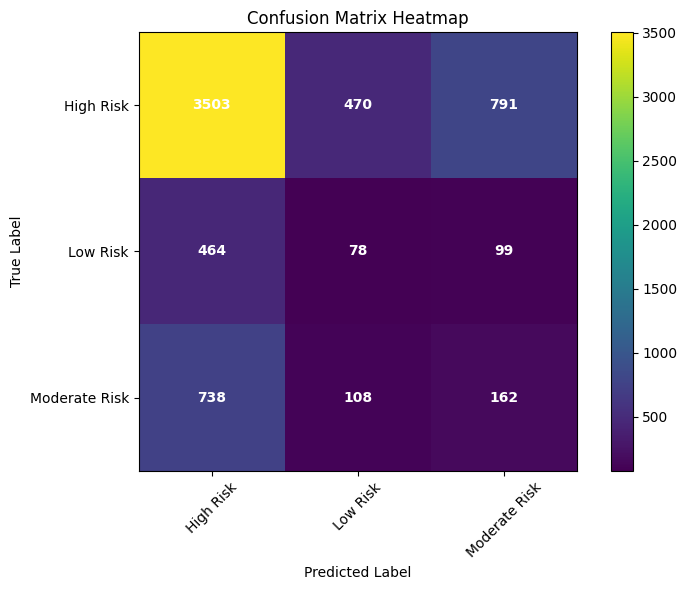

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# --- Confusion Matrix from your output ---
cm = np.array([
    [3503, 470, 791],
    [464, 78, 99],
    [738, 108, 162]
])

classes = ["High Risk", "Low Risk", "Moderate Risk"]

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix Heatmap")
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Print numbers inside the cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                  ha="center", va="center", color="white", fontsize=10, fontweight="bold")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = data1[features_without_leak]
y = data1['risk_classification']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=200,            # more trees = more stable
    max_depth=None,              # allow full depth
    class_weight='balanced',     # VERY IMPORTANT
    random_state=42,
    n_jobs=-1                    # use all CPU cores
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


importances = pd.Series(rf_model.feature_importances_, index=features_without_leak)
print("\nFeature Importance:\n", importances.sort_values(ascending=False))

Accuracy: 0.7428660533291751

Classification Report:
                precision    recall  f1-score   support

    High Risk       0.74      1.00      0.85      4764
     Low Risk       0.00      0.00      0.00       641
Moderate Risk       0.00      0.00      0.00      1008

     accuracy                           0.74      6413
    macro avg       0.25      0.33      0.28      6413
 weighted avg       0.55      0.74      0.63      6413


Confusion Matrix:
 [[4764    0    0]
 [ 641    0    0]
 [1008    0    0]]

Feature Importance:
 lead_time_days                0.111916
supplier_reliability_score    0.111447
order_fulfillment_status      0.111423
delivery_time_deviation       0.111367
customs_clearance_time        0.111045
delay_probability             0.111015
shipping_costs                0.110902
vehicle_gps_longitude         0.110600
vehicle_gps_latitude          0.110284
dtype: float64


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


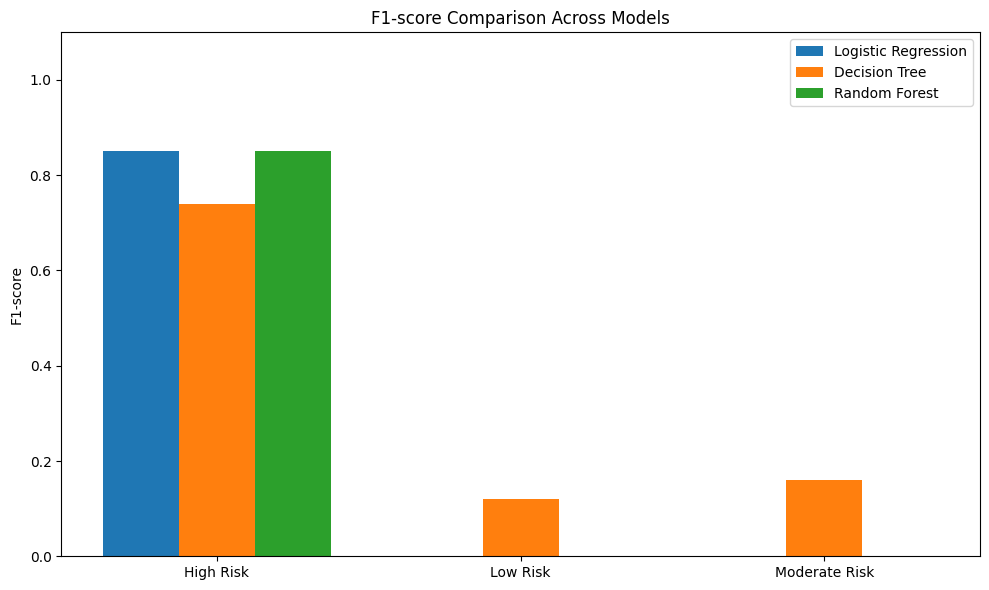

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Class labels
classes = ["High Risk", "Low Risk", "Moderate Risk"]

# ------------------------------
# F1-SCORES FROM YOUR MODELS
# ------------------------------

# Model 1 – Logistic Regression
log_reg_f1 = [0.85, 0.00, 0.00]

# Model 2 – Decision Tree
decision_tree_f1 = [0.74, 0.12, 0.16]

# Model 3 – Random Forest (PLACEHOLDER – update when you send report)
random_forest_f1 = [0.85, 0.00, 0.00]
# ------------------------------
# PLOTTING
# ------------------------------

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(x - width, log_reg_f1, width, label="Logistic Regression")
plt.bar(x, decision_tree_f1, width, label="Decision Tree")
plt.bar(x + width, random_forest_f1, width, label="Random Forest")

plt.xticks(x, classes)
plt.ylabel("F1-score")
plt.title("F1-score Comparison Across Models")
plt.ylim(0, 1.1)
plt.legend()

plt.tight_layout()
plt.show()


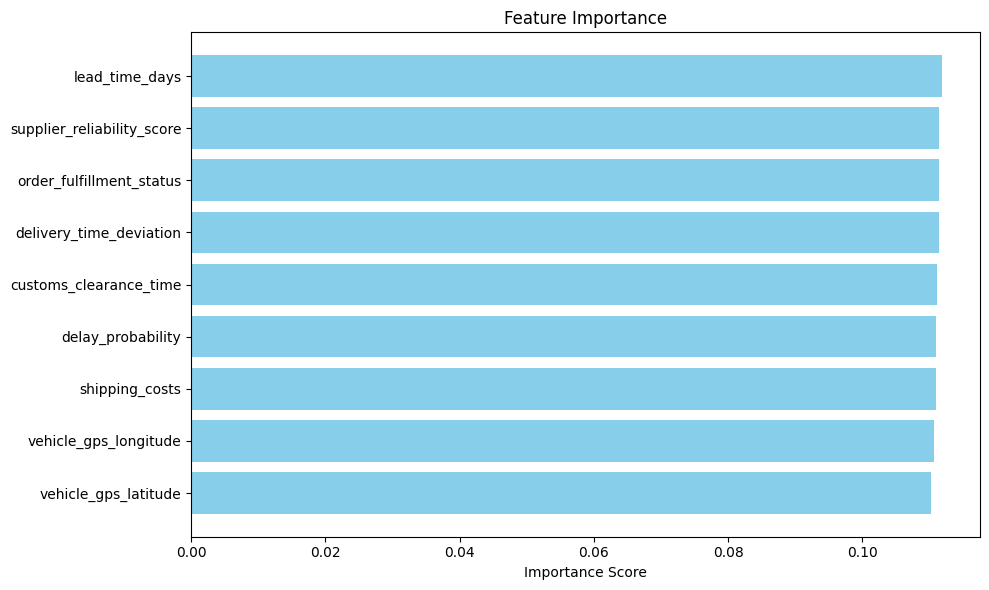

In [10]:
import matplotlib.pyplot as plt

# Data
features = [
    "lead_time_days", "supplier_reliability_score", "order_fulfillment_status",
    "delivery_time_deviation", "customs_clearance_time", "delay_probability",
    "shipping_costs", "vehicle_gps_longitude", "vehicle_gps_latitude"
]

values = [
    0.111916, 0.111447, 0.111423, 0.111367, 0.111045,
    0.111015, 0.110902, 0.110600, 0.110284
]

# Plot
plt.figure(figsize=(10,6))
plt.barh(features[::-1], values[::-1], color='skyblue')  # most important on top
plt.xlabel("Importance Score")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()


In [2]:
import pandas as pd
importances_after = pd.Series(rf_model.feature_importances_, index=X_new.columns)

plt.figure(figsize=(10,6))
importances_after.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Feature Importances (After Removing Leakage)")
plt.ylabel("Importance Score")
plt.show()


NameError: name 'rf_model' is not defined

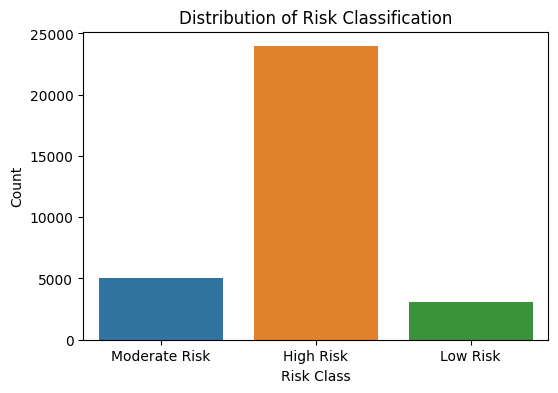

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=data1, x='risk_classification')
plt.title("Distribution of Risk Classification")
plt.xlabel("Risk Class")
plt.ylabel("Count")
plt.show()


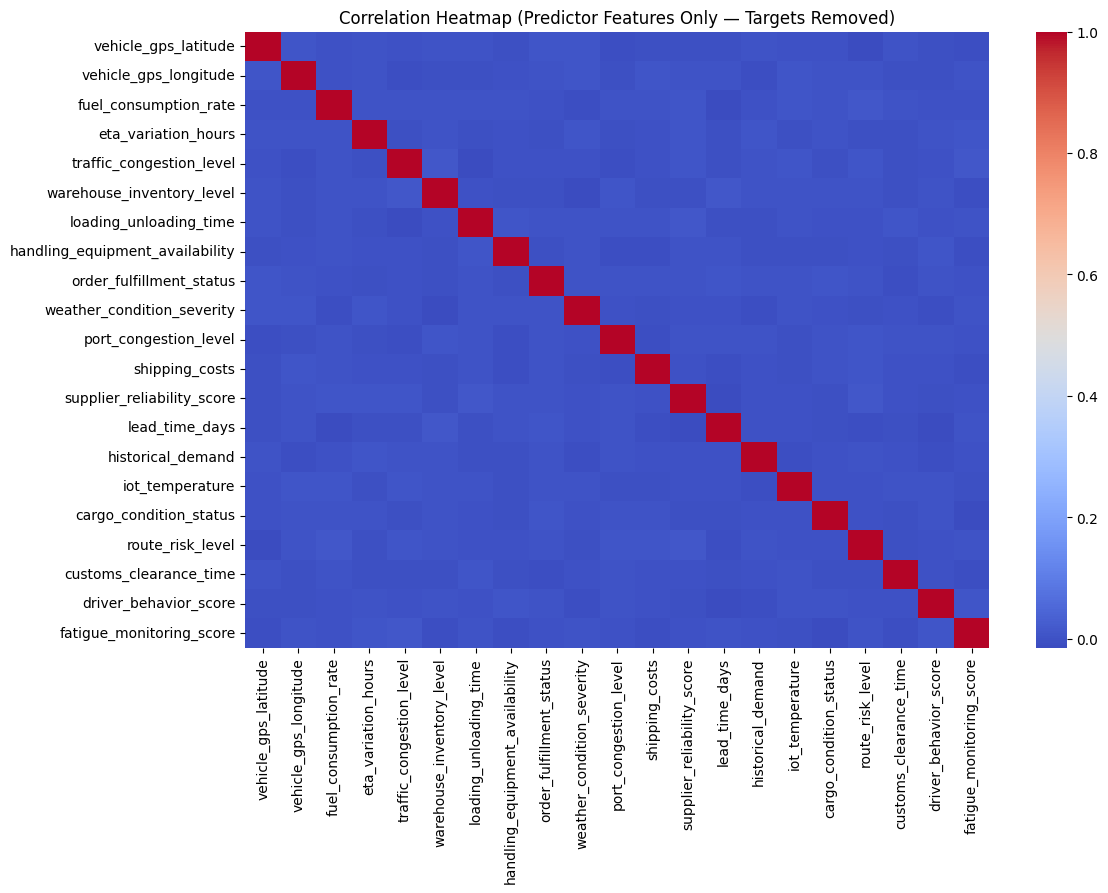

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target / outcome variables to remove
target_cols = [
    'disruption_likelihood_score',
    'delay_probability',
    'risk_classification',
    'delivery_time_deviation'
]

# Remove them if they exist in dataset
cols_to_drop = [col for col in target_cols if col in data1.columns]

# Select numeric predictors only (no targets)
numeric_predictors = data1.drop(columns=cols_to_drop).select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_predictors.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (Predictor Features Only — Targets Removed)")
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


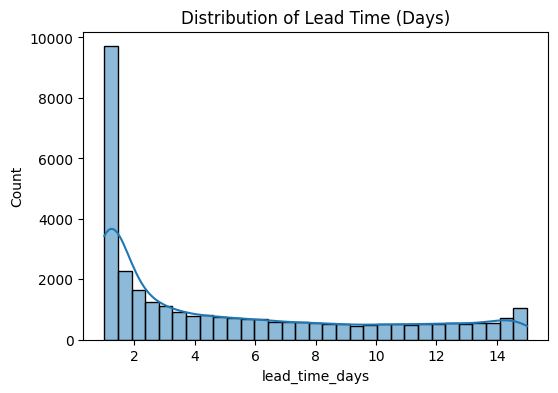

In [4]:
plt.figure(figsize=(6,4))
sns.histplot(data1['lead_time_days'], kde=True)
plt.title("Distribution of Lead Time (Days)")
plt.show()


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False)[:10]

plt.figure(figsize=(8,5))
top10.plot(kind='barh')
plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


NameError: name 'model' is not defined